# IBTrACS storm tracks against the transposition domain & storm catalog

This notebook answers a simple review question:

1. **Was the transposition domain compared to IBTrACS storm tracks to screen for tropical cyclone activity?**

2. **What storms within the storm catalog exist with the IBTrARCS database for storm typing?**

## Data and references

The storm-track source is NOAA/NCEI IBTrACS v04r01:

- IBTrACS access folder: <https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/>
- Line shapefile used here: <https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/shapefile/IBTrACS.since1980.list.v04r01.lines.zip>
- NetCDF used here: <https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/netcdf/IBTrACS.ALL.v04r01.nc>

The local copy, when present, is expected at:

`inputs/IBTrACS_Lines/IBTrACS.since1980.list.v04r01.lines.shp`
`inputs/IBTrACS_Lines/IBTrACS.since1980.v04r01.nc`

If the local shapefile/netCDF is missing, the notebook downloads the NOAA files into `inputs/IBTrACS_Lines/`

The field definitions used below come from the IBTrACS v04r01 column documentation and technical details. Those PDFs live with the project notes and were used to build the classification table.

# Imports

In [1]:
from pathlib import Path
from urllib.request import urlretrieve, Request, urlopen
from zipfile import ZipFile
from io import BytesIO
import math
import os
import tempfile

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from shapely.geometry import box, LineString
import matplotlib.font_manager as _fm
import contextily as cx

try:
    from IPython.display import display
except Exception:
    display = print


import requests
import xarray as xr

# Filepaths & Variables

In [2]:
# Target Watershed Domain
WATERSHED_PATH = Path(
    "/workspaces/meteorology-tools/inputs/watershed/allegheny_huc.geojson"
)
# Geometrically Valid Transposition Domain Produced when Creating the Storm Catalog from Stormhub
VALID_TD_PATH = Path(
    "/workspaces/meteorology-tools/inputs/transposition_domains/allegheny-transpo-area-v01_valid.json"
)
# Ranked Storms CSV Produced when Creating the Storm Catalog from Stormhub
RANKED_STORMS_PATH = Path(
    "/workspaces/meteorology-tools/inputs/storm_catalog/ranked-storms.csv"
)

# Output directory to save figures and data products
OUT_DIR = Path("/workspaces/meteorology-tools/outputs/03_ibtracs_screening")
# IBTraCRS Directory
IBTRACS_DIR = Path("/workspaces/meteorology-tools/inputs/IBTrACS_Lines")
# IBTrACS Storm Track Data for the Atlantic Basin (since 1980)
IBTRACS_SHP = Path(
    "/workspaces/meteorology-tools/inputs/IBTrACS_Lines/IBTrACS.since1980.list.v04r01.lines.shp"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)
JOBLIB_TEMP_DIR = OUT_DIR / "_joblib_temp"
JOBLIB_TEMP_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("JOBLIB_TEMP_FOLDER", str(JOBLIB_TEMP_DIR))
os.environ.setdefault("TMPDIR", str(JOBLIB_TEMP_DIR))
os.environ.setdefault("TEMP", str(JOBLIB_TEMP_DIR))
os.environ.setdefault("TMP", str(JOBLIB_TEMP_DIR))
tempfile.tempdir = str(JOBLIB_TEMP_DIR)

IBTRACS_SHP_URL = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/shapefile/IBTrACS.since1980.list.v04r01.lines.zip"
IBTRACS_NC_URL = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/netcdf/IBTrACS.since1980.v04r01.nc"
TARGET_CRS = "EPSG:5070"
GEOG_CRS = "EPSG:4326"
PLOT_CRS = "EPSG:3857"
OSM_BASEMAP_SOURCE = cx.providers.OpenStreetMap.Mapnik
OSM_BASEMAP_ZOOM = 6
CONUS_BOUNDS_4326 = (-125.0, 24.0, -66.0, 50.5)
M_PER_MI = 1609.344
M2_PER_MI2 = 2_589_988.110336
SELECTED_GSL = 0.0
NUM_STORMS = 450

_available = {f.name for f in _fm.fontManager.ttflist}
PLOT_FONT = next(
    (f for f in ["Arial", "Liberation Sans", "DejaVu Sans"] if f in _available),
    "sans-serif",
)
PLOT_FONT_SIZE = 20
mpl.rcParams.update(
    {
        "font.family": PLOT_FONT,
        "font.size": PLOT_FONT_SIZE,
        "axes.titlesize": PLOT_FONT_SIZE,
        "axes.labelsize": PLOT_FONT_SIZE,
        "xtick.labelsize": PLOT_FONT_SIZE,
        "ytick.labelsize": PLOT_FONT_SIZE,
        "legend.fontsize": PLOT_FONT_SIZE - 7,
    }
)

for p in [WATERSHED_PATH, VALID_TD_PATH]:
    assert p.exists(), p
print("inputs OK")
print("outputs ->", OUT_DIR)

inputs OK
outputs -> /workspaces/meteorology-tools/outputs/03_ibtracs_screening


# Functions

In [ ]:
def ensure_ibtracs_lines():
    """Use the local IBTrACS line shapefile or download it from NOAA if needed."""
    if IBTRACS_SHP.exists():
        print("IBTrACS local shapefile found:", IBTRACS_SHP)
        return IBTRACS_SHP

    IBTRACS_DIR.mkdir(parents=True, exist_ok=True)
    zip_path = IBTRACS_DIR / Path(IBTRACS_SHP_URL).name
    if not zip_path.exists():
        print("Downloading IBTrACS line shapefile from NOAA...")
        print(IBTRACS_SHP_URL)
        urlretrieve(IBTRACS_SHP_URL, zip_path)
    else:
        print("IBTrACS zip already present:", zip_path)

    print("Unzipping IBTrACS line shapefile...")
    with ZipFile(zip_path) as zf:
        zf.extractall(IBTRACS_DIR)

    if not IBTRACS_SHP.exists():
        raise FileNotFoundError(f"Expected shapefile after unzip: {IBTRACS_SHP}")
    return IBTRACS_SHP


def polygon_hole_count(geom):
    if geom.is_empty:
        return 0
    if geom.geom_type == "Polygon":
        return len(geom.interiors)
    if geom.geom_type == "MultiPolygon":
        return sum(len(poly.interiors) for poly in geom.geoms)
    return 0


def polygon_check_summary(gdf, name):
    geom = gdf.geometry.union_all()
    parts = len(geom.geoms) if geom.geom_type == "MultiPolygon" else 1
    print(
        f"{name}: valid={geom.is_valid}; parts={parts}; holes={polygon_hole_count(geom)}"
    )


def check_watershed_within_td(watershed_gdf, td_gdf, label):
    watershed_geom = watershed_gdf.geometry.union_all()
    td_geom = td_gdf.geometry.union_all()
    print(f"Watershed inside {label}: {watershed_geom.within(td_geom)}")


def basemap_axes(
    ax,
    frame_gdf,
    pad_frac=0.05,
    basemap=True,
    basemap_source=None,
    basemap_alpha=1.0,
    basemap_zoom=OSM_BASEMAP_ZOOM,
    scale_bar=True,
    north_arrow=True,
):
    minx, miny, maxx, maxy = frame_gdf.to_crs(PLOT_CRS).total_bounds
    padx = (maxx - minx) * pad_frac
    pady = (maxy - miny) * pad_frac
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    if basemap:
        import contextily as cx

        src = basemap_source if basemap_source is not None else OSM_BASEMAP_SOURCE
        cx.add_basemap(
            ax,
            crs=PLOT_CRS,
            source=src,
            zoom=basemap_zoom,
            alpha=basemap_alpha,
            attribution_size=6,
        )
    ax.set_axis_off()

    if scale_bar:
        center_lat_deg = (
            frame_gdf.to_crs(TARGET_CRS).geometry.centroid.to_crs(GEOG_CRS).y.iloc[0]
        )
        cos_lat = math.cos(math.radians(center_lat_deg))
        ft_per_unit = 111_319.5 * cos_lat * 3.28084
        ax.add_artist(
            ScaleBar(
                ft_per_unit,
                units="ft",
                dimension="imperial-length",
                fixed_value=100,
                fixed_units="mi",
                location="lower right",
                box_alpha=0.85,
                rotation="horizontal-only",
                font_properties={"family": PLOT_FONT, "size": PLOT_FONT_SIZE - 5},
            )
        )
    if north_arrow:
        ax.annotate(
            "",
            xy=(0.97, 0.95),
            xytext=(0.97, 0.86),
            arrowprops=dict(
                facecolor="black",
                edgecolor="black",
                width=5,
                headwidth=18,
                headlength=18,
            ),
            xycoords=ax.transAxes,
        )
        ax.text(
            0.97,
            0.96,
            "N",
            ha="center",
            va="bottom",
            fontsize=PLOT_FONT_SIZE,
            fontweight="bold",
            transform=ax.transAxes,
        )


def add_scale_bar_and_north_arrow(ax, frame_gdf_5070, length_mi=100):
    # Use bounds midpoint instead of union_all() to avoid geometry backend issues
    minx, miny, maxx, maxy = frame_gdf_5070.total_bounds
    center_geom = gpd.points_from_xy([(minx + maxx) / 2], [(miny + maxy) / 2])[0]
    center_lat_deg = (
        gpd.GeoSeries([center_geom], crs=TARGET_CRS).to_crs(GEOG_CRS).y.iloc[0]
    )

    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    width = x1 - x0
    height = y1 - y0

    length_axis_units = (length_mi * M_PER_MI) / max(
        math.cos(math.radians(center_lat_deg)), 1e-6
    )
    x_end = x0 + 0.18 * width
    x_start = x_end - length_axis_units
    y = y0 + 0.055 * height

    ax.plot(
        [x_start, x_end],
        [y, y],
        color="black",
        linewidth=6,
        solid_capstyle="butt",
        zorder=20,
    )
    ax.plot(
        [x_start, x_start],
        [y - 0.006 * height, y + 0.006 * height],
        color="black",
        linewidth=2,
        zorder=20,
    )
    ax.plot(
        [x_end, x_end],
        [y - 0.006 * height, y + 0.006 * height],
        color="black",
        linewidth=2,
        zorder=20,
    )
    ax.text(
        (x_start + x_end) / 2,
        y + 0.014 * height,
        f"{length_mi:g} mi",
        ha="center",
        va="bottom",
        fontsize=PLOT_FONT_SIZE - 5,
        color="black",
        zorder=20,
    )

    ax.annotate(
        "",
        xy=(0.955, 0.14),
        xytext=(0.955, 0.05),
        arrowprops=dict(
            facecolor="black", edgecolor="black", width=4, headwidth=16, headlength=16
        ),
        xycoords=ax.transAxes,
    )
    ax.text(
        0.955,
        0.155,
        "N",
        ha="center",
        va="bottom",
        fontsize=PLOT_FONT_SIZE - 1,
        fontweight="bold",
        transform=ax.transAxes,
    )


def set_plot_extent(ax, frame_gdf_5070, pad_frac=0.06):
    bounds = frame_gdf_5070.to_crs(PLOT_CRS).total_bounds
    minx, miny, maxx, maxy = bounds
    padx = (maxx - minx) * pad_frac
    pady = (maxy - miny) * pad_frac
    ax.set_xlim(minx - padx, maxx + padx)
    ax.set_ylim(miny - pady, maxy + pady)
    ax.set_axis_off()


def download_and_load_netcdf(
    url: str,
    output_dir: str | Path,
    overwrite: bool = False,
    timeout: int = 300,
    chunks: dict | None = None,
) -> tuple[xr.Dataset, Path]:
    """
    Download a NetCDF file and load it with xarray.

    Parameters
    ----------
    url : str
        URL to the NetCDF file.
    output_dir : str | Path
        Directory where the file should be stored.
    overwrite : bool, optional
        Re-download if file already exists.
    timeout : int, optional
        Download timeout in seconds.
    chunks : dict, optional
        Dask chunk configuration passed to xr.open_dataset().

    Returns
    -------
    tuple[xr.Dataset, Path]
        Loaded xarray Dataset and local file path.
    """
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    nc_path = output_dir / Path(url).name

    # Download if needed
    if overwrite or not nc_path.exists():
        with requests.get(url, stream=True, timeout=timeout) as r:
            r.raise_for_status()

            with open(nc_path, "wb") as f:
                for chunk in r.iter_content(chunk_size=1024 * 1024):
                    if chunk:
                        f.write(chunk)

    # Open with xarray
    ds = xr.open_dataset(
        nc_path,
        chunks=chunks,
        decode_times=True,
    )

    return ds, nc_path

## Domain checks

In [4]:
watershed = gpd.read_file(WATERSHED_PATH).to_crs(TARGET_CRS)
valid_td = gpd.read_file(VALID_TD_PATH).to_crs(TARGET_CRS)

map_frame = gpd.GeoDataFrame(
    geometry=[box(*CONUS_BOUNDS_4326)],
    crs=GEOG_CRS,
).to_crs(TARGET_CRS)

print(f"Watershed area: {watershed.area.sum() / M2_PER_MI2:,.0f} mi2")
print(f"Valid TD area: {valid_td.area.sum() / M2_PER_MI2:,.0f} mi2")
polygon_check_summary(watershed, "Watershed")
check_watershed_within_td(watershed, valid_td, "transposition domain")

Watershed area: 11,729 mi2
Valid TD area: 200,121 mi2
Watershed: valid=True; parts=1; holes=0
Watershed inside transposition domain: True


## IBTrACS lines in the map window

The notebook does not trim the storm lines. It reads the tracks that intersect the plotting window and keeps each geometry whole.

In [5]:
ibtracs_path = ensure_ibtracs_lines()
plot_bounds_4326 = CONUS_BOUNDS_4326

try:
    ib = gpd.read_file(ibtracs_path, bbox=plot_bounds_4326, columns=["SID", "USA_SSHS"])
except TypeError:
    ib = gpd.read_file(ibtracs_path, bbox=plot_bounds_4326)
    keep = [c for c in ["SID", "USA_SSHS", "geometry"] if c in ib.columns]
    ib = ib[keep]

ib["USA_SSHS"] = pd.to_numeric(ib["USA_SSHS"], errors="coerce").fillna(-5).astype(int)
ib["USA_SSHS"] = ib["USA_SSHS"].clip(-5, 5)

sshs_lookup = pd.DataFrame(
    [
        (-5, "Unknown", "Unknown status or missing classification"),
        (
            -4,
            "Post-tropical / Extratropical",
            "Extratropical, extrapolated, or post-tropical: EX, ET, PT",
        ),
        (
            -3,
            "Disturbance",
            "Wave, low, disturbance, dissipating, inland, or monsoon depression: WV, LO, DB, DS, IN, MD",
        ),
        (-2, "Subtropical", "Subtropical storm or subtropical depression: SS, SD"),
        (-1, "Tropical Depression", "Tropical system with wind speed less than 34 kt"),
        (0, "Tropical Storm", "Tropical system with wind speed from 34 to 63 kt"),
        (1, "Hurricane Category 1", "64 to 82 kt"),
        (2, "Hurricane Category 2", "83 to 95 kt"),
        (3, "Hurricane Category 3", "96 to 112 kt"),
        (4, "Hurricane Category 4", "113 to 136 kt"),
        (5, "Hurricane Category 5", "137 kt or greater"),
    ],
    columns=["USA_SSHS", "Class", "Description"],
)

ib = ib.merge(sshs_lookup[["USA_SSHS", "Class"]], on="USA_SSHS", how="left")
ib["Class"] = ib["Class"].fillna("Unknown")

sshs_summary = (
    ib.groupby(["USA_SSHS", "Class"])
    .agg(line_segments=("SID", "size"), unique_storms=("SID", "nunique"))
    .reset_index()
    .sort_values("USA_SSHS")
)

print(f"Loaded {len(ib):,} IBTrACS line segments in the map window.")
print(f"Unique storms represented: {ib['SID'].nunique():,}")
display(sshs_summary)

IBTrACS local shapefile found: /workspaces/meteorology-tools/inputs/IBTrACS_Lines/IBTrACS.since1980.list.v04r01.lines.shp
Loaded 12,286 IBTrACS line segments in the map window.
Unique storms represented: 524


,USA_SSHS,Class,line_segments,unique_storms
0,-5,Unknown,12,10
1,-4,Post-tropical / Extratropical,931,105
2,-3,Disturbance,1526,150
3,-2,Subtropical,480,43
4,-1,Tropical Depression,2766,315
5,0,Tropical Storm,3975,363
6,1,Hurricane Category 1,1278,184
7,2,Hurricane Category 2,638,96
8,3,Hurricane Category 3,365,65
9,4,Hurricane Category 4,269,39


## USA SSHS reference

Negative values are lifecycle or disturbance labels. Positive values are the hurricane categories used in the map.

In [6]:
display(sshs_lookup)

,USA_SSHS,Class,Description
0,-5,Unknown,Unknown status or missing classification
1,-4,Post-tropical / Extratropical,"Extratropical, extrapolated, or post-tropical:..."
2,-3,Disturbance,"Wave, low, disturbance, dissipating, inland, o..."
3,-2,Subtropical,Subtropical storm or subtropical depression: S...
4,-1,Tropical Depression,Tropical system with wind speed less than 34 kt
5,0,Tropical Storm,Tropical system with wind speed from 34 to 63 kt
6,1,Hurricane Category 1,64 to 82 kt
7,2,Hurricane Category 2,83 to 95 kt
8,3,Hurricane Category 3,96 to 112 kt
9,4,Hurricane Category 4,113 to 136 kt


## Tracks classified by USA SSHS

The only figure in this notebook shows the watershed, the transposition domain, the valid TD, and the IBTrACS line tracks using the USA SSHS classification.

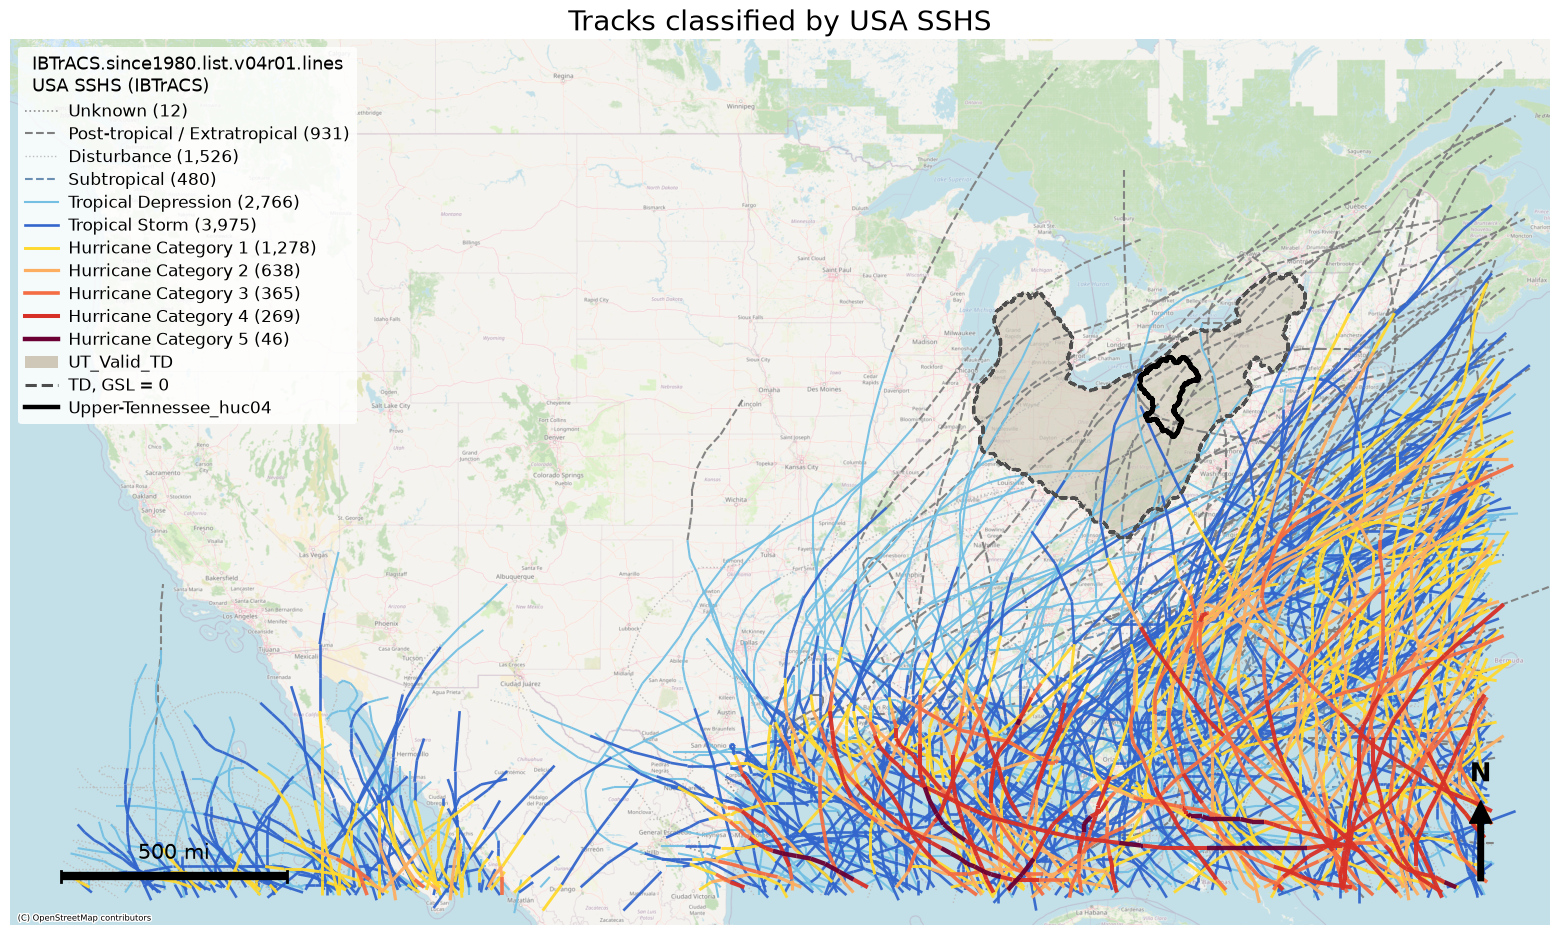

In [7]:
style_map = {
    -5: {"color": "#8c8c8c", "linestyle": ":", "linewidth": 1.2},
    -4: {"color": "#7f7f7f", "linestyle": "--", "linewidth": 1.5},
    -3: {"color": "#bdbdbd", "linestyle": ":", "linewidth": 1.0},
    -2: {"color": "#6b8fb3", "linestyle": "--", "linewidth": 1.5},
    -1: {"color": "#74c0e3", "linestyle": "-", "linewidth": 1.5},
    0: {"color": "#3366cc", "linestyle": "-", "linewidth": 1.9},
    1: {"color": "#ffd92f", "linestyle": "-", "linewidth": 2.1},
    2: {"color": "#fdae61", "linestyle": "-", "linewidth": 2.3},
    3: {"color": "#f46d43", "linestyle": "-", "linewidth": 2.6},
    4: {"color": "#d73027", "linestyle": "-", "linewidth": 2.9},
    5: {"color": "#6a0033", "linestyle": "-", "linewidth": 3.2},
}

fig, ax = plt.subplots(figsize=(16, 13))
basemap_axes(
    ax, map_frame, pad_frac=0.05, basemap_alpha=0.70, scale_bar=False, north_arrow=False
)

valid_td.to_crs(PLOT_CRS).plot(
    ax=ax, facecolor="#cfc8b8", edgecolor="none", alpha=0.65, zorder=1
)

for cat in [-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5]:
    sub = ib[ib["USA_SSHS"] == cat]
    if len(sub):
        sub.to_crs(PLOT_CRS).plot(
            ax=ax,
            color=style_map[cat]["color"],
            linewidth=style_map[cat]["linewidth"],
            linestyle=style_map[cat]["linestyle"],
            alpha=0.95,
            zorder=3,
        )

valid_td.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor="#4d4d4d", linewidth=2.2, linestyle="--", zorder=4
)
watershed.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor="black", linewidth=3.2, zorder=5
)

add_scale_bar_and_north_arrow(ax, map_frame, length_mi=500)
ax.set_title("Tracks classified by USA SSHS")

legend_handles = []
for _, row in sshs_lookup.iterrows():
    cat = int(row["USA_SSHS"])
    legend_handles.append(
        Line2D(
            [],
            [],
            color=style_map[cat]["color"],
            linewidth=style_map[cat]["linewidth"],
            linestyle=style_map[cat]["linestyle"],
            label=f"{row['Class']} ({int(sshs_summary.loc[sshs_summary['USA_SSHS'] == cat, 'line_segments'].sum()):,})",
        )
    )
legend_handles.extend(
    [
        Patch(facecolor="#cfc8b8", edgecolor="none", label="UT_Valid_TD"),
        Line2D(
            [], [], color="#4d4d4d", linewidth=2.2, linestyle="--", label="TD, GSL = 0"
        ),
        Line2D([], [], color="black", linewidth=3.2, label="Upper-Tennessee_huc04"),
    ]
)

legend = ax.legend(
    handles=legend_handles,
    loc="upper left",
    title="IBTrACS.since1980.list.v04r01.lines\nUSA SSHS (IBTrACS)",
    frameon=True,
    framealpha=0.85,
    facecolor="white",
    edgecolor="none",
    fontsize=PLOT_FONT_SIZE - 8,
    title_fontsize=PLOT_FONT_SIZE - 7,
    labelspacing=0.35,
    handlelength=2.0,
    handletextpad=0.6,
)
legend.get_frame().set_linewidth(0.0)

fig.tight_layout()
fig.savefig(OUT_DIR / "ibtracs_usa_sshs_tracks.png", dpi=220, bbox_inches="tight")
plt.show()

The figure above is the screening check. The domain is shown against the full storm lines, and the lines stay intact while the notebook classifies them by USA SSHS.

# Cross Reference Storm Catalog with IBTrACS

In [8]:
storms_df = pd.read_csv(RANKED_STORMS_PATH)
storms_df["storm_type"] = pd.Series(pd.NA, index=storms_df.index, dtype="string")

print(storms_df.head(5))

ib_ds, nc_path = download_and_load_netcdf(
    url=IBTRACS_NC_URL,
    output_dir=IBTRACS_DIR,
    chunks={"storm": 1000},
)
print(f"Loaded IBTrACS NetCDF: {nc_path} with {len(ib_ds.storm):,} storms.")

      storm_date  mean   min    max  por_rank  annual_rank storm_type
0  2011-09-06T00  6.32  0.37  14.99         1            1       <NA>
1  2008-09-12T00  6.11  1.11   9.79         2            1       <NA>
2  1986-09-10T00  5.77  0.70  11.04         3            1       <NA>
3  2018-09-08T00  5.13  1.49   8.15         4            1       <NA>
4  1985-11-02T00  5.09  1.93  14.23         5            1       <NA>


Loaded IBTrACS NetCDF: /workspaces/meteorology-tools/inputs/IBTrACS_Lines/IBTrACS.since1980.v04r01.nc with 4,946 storms.


/workspaces/meteorology-tools/outputs/03_ibtracs_screening/_joblib_temp/ipykernel_8147/4107870941.py:191: UserWarning: The specified chunks separate the stored chunks along dimension "storm" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  ds = xr.open_dataset(


## Spatial-Temporal Filter
Identify relevant storms from the IBTrACS database based on spatial proximity to the transposition domain (i.e., within the bounding box) and temporal overlap with the start date of the storm as determined by stormhub.

In [9]:
ibtracs_storms = {}

# Use geographic bounds (lon/lat degrees) for masking against IBTrACS lon/lat
lon_min, lat_min, lon_max, lat_max = valid_td.to_crs(GEOG_CRS).total_bounds

spatial_mask = (
    (ib_ds["lon"] >= lon_min)
    & (ib_ds["lon"] <= lon_max)
    & (ib_ds["lat"] >= lat_min)
    & (ib_ds["lat"] <= lat_max)
)

# Materialize boolean indexers/times to avoid dask shape issues
storms_with_hits = spatial_mask.any(dim="date_time").compute()
subset = ib_ds.where(storms_with_hits, drop=True)
hit_times = (
    ib_ds["time"].where(spatial_mask).where(storms_with_hits, drop=True).compute()
)

# Cache in-domain hit times by storm so comparisons use actual in-domain timestamps
storm_hit_times = {}
for storm in subset.storm.values:
    tvals = pd.to_datetime(hit_times.sel(storm=storm).values, errors="coerce")
    tvals = tvals[~pd.isna(tvals)]
    if len(tvals) > 0:
        storm_hit_times[storm] = pd.DatetimeIndex(tvals)

for idx, row in storms_df.iterrows():
    storm_rank = row["por_rank"]
    storm_date = row["storm_date"]
    storm_start = pd.to_datetime(storm_date, errors="coerce")
    if pd.isna(storm_start):
        continue
    storm_end = storm_start + pd.Timedelta(days=3)

    for storm, times in storm_hit_times.items():
        in_window = ((times >= storm_start) & (times <= storm_end)).any()
        if in_window:
            storm_subset = subset.sel(storm=storm)
            sid_val = str(np.asarray(storm_subset["sid"].values).item())
            ibtracs_storms.setdefault(storm_date, []).append(
                {
                    "sid": sid_val,
                    "ds": storm_subset,
                    "storm_rank": storm_rank,
                }
            )
print(f"Matched catalog dates: {len(ibtracs_storms):,}")

/opt/conda/envs/mtools-base/lib/python3.12/site-packages/xarray/coding/times.py:670: RuntimeWarning: invalid value encountered in cast
  flat_num = flat_num.astype(np.int64)


Matched catalog dates: 56


## Assign Storm Types: Tropical vs Non-Tropical

In [10]:
mask = storms_df["storm_date"].isin(ibtracs_storms.keys())
storms_df["storm_type"] = pd.Series(
    "Non-Tropical", index=storms_df.index, dtype="string"
)
storms_df.loc[mask, "storm_type"] = "Tropical Cyclone"

tropical_storms = storms_df[
    (storms_df["storm_type"] == "Tropical Cyclone")
    & (storms_df["por_rank"] <= NUM_STORMS)
]
print(f"Catalog tropical storms: {len(tropical_storms):,}")
percent_tropical = len(tropical_storms) / len(storms_df) * 100
print(f"Percent of catalog storms that are tropical: {percent_tropical:.2f}%")
tropical_storms

Catalog tropical storms: 30
Percent of catalog storms that are tropical: 1.84%


,storm_date,mean,min,max,por_rank,annual_rank,storm_type
1,2008-09-12T00,6.11,1.11,9.79,2,1,Tropical Cyclone
6,2004-09-16T00,4.68,1.47,8.36,7,1,Tropical Cyclone
7,2004-09-07T00,4.45,1.85,9.04,8,2,Tropical Cyclone
9,2012-10-29T00,4.30,2.09,10.45,10,1,Tropical Cyclone
15,2005-08-30T00,4.04,1.26,8.97,16,1,Tropical Cyclone
16,1999-09-15T00,3.96,1.47,8.64,17,1,Tropical Cyclone
18,1996-09-04T00,3.91,0.37,13.33,19,1,Tropical Cyclone
25,2011-08-28T00,3.78,0.52,14.28,26,2,Tropical Cyclone
32,2021-08-30T00,3.63,0.98,6.84,33,2,Tropical Cyclone
38,2024-08-07T00,3.52,0.25,10.03,39,2,Tropical Cyclone


Text(0.5, 1.0, 'Cross Referenced Storm Catalog with IBTrACS (Colored by Rank)')

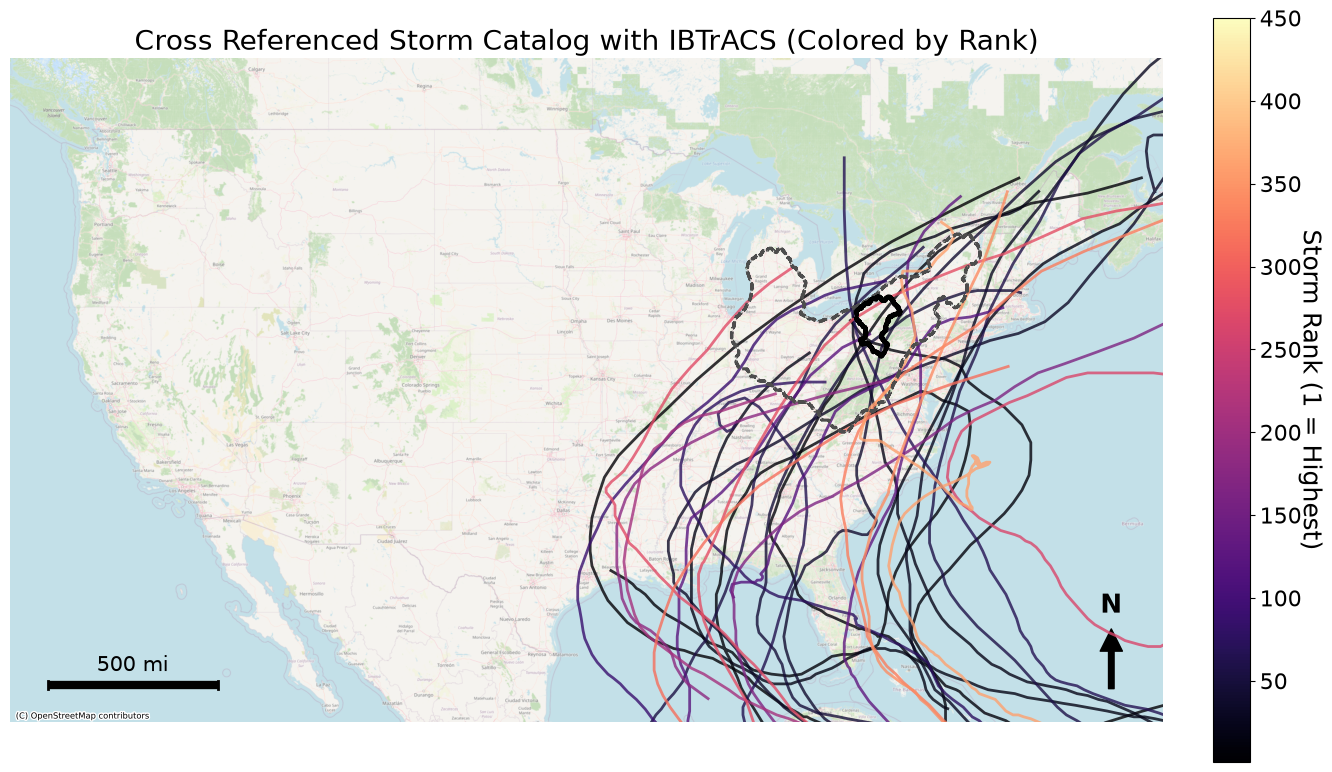

In [11]:
# create a single plot with all storm paths colored by their rank
fig, ax = plt.subplots(figsize=(16, 13))
basemap_axes(
    ax, map_frame, pad_frac=0.05, basemap_alpha=0.70, scale_bar=False, north_arrow=False
)
valid_td.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor="#4d4d4d", linewidth=2.2, linestyle="--", zorder=4
)
watershed.to_crs(PLOT_CRS).boundary.plot(
    ax=ax, edgecolor="black", linewidth=3.2, zorder=5
)

add_scale_bar_and_north_arrow(ax, map_frame, length_mi=500)
ax.set_title("Tracks classified by USA SSHS")

# plot all storm tracks in the catalog, colored by rank
for storm_date, entries in ibtracs_storms.items():
    for entry in entries:
        storm_subset = entry["ds"]
        storm_rank = entry["storm_rank"]
        if storm_rank > NUM_STORMS:
            continue  # skip low-ranked storms

        # Build a clean lon/lat table and drop invalid points before making a track line
        storm_xy = pd.DataFrame(
            {
                "lon": np.asarray(storm_subset["lon"].values).astype(float),
                "lat": np.asarray(storm_subset["lat"].values).astype(float),
            }
        )
        storm_xy = storm_xy.replace([np.inf, -np.inf], np.nan).dropna(
            subset=["lon", "lat"]
        )

        # GEOS LineString requires either 0 points or >= 2 points
        if len(storm_xy) < 2:
            continue

        storm_line = LineString(zip(storm_xy["lon"], storm_xy["lat"]))
        storm_subset_gdf = gpd.GeoDataFrame(geometry=[storm_line], crs=GEOG_CRS).to_crs(
            PLOT_CRS
        )
        storm_subset_gdf.plot(
            ax=ax,
            color=plt.cm.magma(storm_rank / NUM_STORMS),
            linewidth=2.0,
            alpha=0.8,
            zorder=3,
        )

# add a colorbar
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.magma,
    norm=plt.Normalize(vmin=storms_df["por_rank"].min(), vmax=NUM_STORMS),
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, fraction=0.03, pad=0.04)
cbar.set_label(
    "Storm Rank (1 = Highest)", rotation=270, labelpad=15, fontsize=PLOT_FONT_SIZE - 2
)
cbar.ax.tick_params(labelsize=PLOT_FONT_SIZE - 4)
ax.set_title("Cross Referenced Storm Catalog with IBTrACS (Colored by Rank)")

In [12]:
# create individual images for each storm in the catalog, colored by rank
storms_list = []
for storm_date, entries in ibtracs_storms.items():
    for entry in entries:
        storm_subset = entry["ds"]
        storm_rank = entry["storm_rank"]
        if storm_rank > NUM_STORMS:
            continue  # skip low-ranked storms

        lat = np.asarray(storm_subset["lat"].values).astype(float)
        lon = np.asarray(storm_subset["lon"].values).astype(float)
        storms_list.append((storm_date, storm_rank, lat, lon))

        # Build a clean lon/lat table and drop invalid points before making a track line
        storm_xy = pd.DataFrame(
            {
                "lon": lon,
                "lat": lat,
            }
        )
        storm_xy = storm_xy.replace([np.inf, -np.inf], np.nan).dropna(
            subset=["lon", "lat"]
        )

        # GEOS LineString requires either 0 points or >= 2 points
        if len(storm_xy) < 2:
            continue

        storm_line = LineString(zip(storm_xy["lon"], storm_xy["lat"]))
        storm_subset_gdf = gpd.GeoDataFrame(geometry=[storm_line], crs=GEOG_CRS).to_crs(
            PLOT_CRS
        )

        fig, ax = plt.subplots(figsize=(16, 13))
        basemap_axes(
            ax,
            map_frame,
            pad_frac=0.05,
            basemap_alpha=0.70,
            scale_bar=False,
            north_arrow=False,
        )
        valid_td.to_crs(PLOT_CRS).boundary.plot(
            ax=ax, edgecolor="#4d4d4d", linewidth=2.2, linestyle="--", zorder=4
        )
        watershed.to_crs(PLOT_CRS).boundary.plot(
            ax=ax, edgecolor="black", linewidth=3.2, zorder=5
        )

        add_scale_bar_and_north_arrow(ax, map_frame, length_mi=500)
        ax.set_title(f"Storm Date: {storm_date} | Rank: {storm_rank}")

        storm_subset_gdf.plot(
            ax=ax,
            color=plt.cm.magma(storm_rank / NUM_STORMS),
            linewidth=2.0,
            alpha=0.8,
            zorder=3,
        )

        fig.tight_layout()
        output_file = OUT_DIR / f"storm_{storm_date}_rank_{storm_rank}.png"
        fig.savefig(output_file, dpi=220, bbox_inches="tight")
        plt.close(fig)

# Manual Inspection
The individual storm tracks were saved as PNG files to the location as defined by the variable OUT_DIR. Navigate to this location to begin inspecting each of the storm tracks for potential tropical storm classifications.

In [13]:
# compile list into a DataFrame for reference
storms_df = pd.DataFrame(
    storms_list, columns=["storm_date", "storm_rank", "lat", "lon"]
)
storms_df.to_csv(OUT_DIR / "addtl_tropical_storms.csv", index=False)
print(f"Saved tropical storms catalog to {OUT_DIR / 'addtl_tropical_storms.csv'}")

Saved tropical storms catalog to /workspaces/meteorology-tools/outputs/03_ibtracs_screening/addtl_tropical_storms.csv
